# 09. Финальные артефакты и сводные результаты

**Цель:** cобрать все артефакты проекта в единый, переносимый набор: проверить, что каждый из 7 артефактов загружается и работает, построить сводные таблицы и графики.

**Содержание:**
1. Аудит всех артефактов в `artifacts/`
2. Оценка test каждой моделью (для построения ROC/PR на одной оси).
3. Единая сравнительная таблица 7 моделей.
4. Per-class accuracy матрица: 14 типов атак x 7 моделей.
5. Сводные графики: ROC, PR, F1-vs-time, F1-vs-size.
6. `model_registry_manifest.json` — финальный реестр артефактов.

In [ ]:
from __future__ import annotations

import json
import shutil
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR = PROJECT_ROOT / "cache"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
SRC_DIR   = PROJECT_ROOT / "src"
MODELS_DIR_SRC = PROJECT_ROOT / "models"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict
from models.architectures import (                                   
    TabularAutoencoder, TabularMLP, TabularFTTransformer,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [ ]:
X_test  = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_test  = pd.read_parquet(CACHE_DIR / "y_test.parquet")["target"].values
X_test_np = X_test.values.astype(np.float32)

with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]
assert list(X_test.columns) == MODEL_FEATURES

# Поднятие оригинальных labels для test — для per-class анализа
df_labels = pd.read_parquet(CACHE_DIR / "nfs_2023_nte_all.parquet",
                            columns=["label"])
y_full = (df_labels["label"].astype(str).str.strip().str.upper()
          != "BENIGN").astype(np.int64).values
_, label_test_raw = train_test_split(
    df_labels["label"].values, test_size=0.30,
    stratify=y_full, random_state=RANDOM_STATE,
)
assert len(label_test_raw) == len(y_test)
print(f"X_test: {X_test_np.shape}")
print(f"Уникальных labels в test: {len(set(label_test_raw))}")

X_test: (633340, 42)
Уникальных labels в test: 15


## 1. Проверка и загрузка артефактов

In [3]:
ARTIFACT_REGISTRY = [
    # (display_name, filename, type, category)
    ("RandomForest",   "model_rf_baseline.joblib",   "sklearn",  "tree_ensemble"),
    ("XGBoost",        "model_xgboost.joblib",       "sklearn",  "tree_ensemble"),
    ("LightGBM",       "model_lightgbm.joblib",      "sklearn",  "tree_ensemble"),
    ("DecisionTree",   "model_decisiontree.joblib",  "sklearn",  "tree_single"),
    ("GaussianNB",     "model_gaussiannb.joblib",    "sklearn",  "linear_baseline"),
    ("MLP",            "model_mlp.joblib",           "pytorch",  "nn_supervised"),
    ("FT-Transformer", "model_ft_transformer.joblib","pytorch",  "nn_supervised"),
    ("Autoencoder",    "model_autoencoder.joblib",   "pytorch",  "nn_unsupervised"),
]

inventory_rows = []
for name, fname, kind, category in ARTIFACT_REGISTRY:
    p = ARTIFACTS / fname
    exists = p.exists()
    inventory_rows.append({
        "model":    name,
        "file":     fname,
        "type":     kind,
        "category": category,
        "exists":   exists,
        "size_kb":  round(p.stat().st_size / 1024, 1) if exists else None,
    })
inv = pd.DataFrame(inventory_rows)
print(inv.to_string(index=False))
assert inv["exists"].all(), "Не все артефакты на месте!"
print(f"\nВсе {len(inv)} артефактов найдены.")

         model                        file    type        category  exists  size_kb
  RandomForest    model_rf_baseline.joblib sklearn   tree_ensemble    True   1896.4
       XGBoost        model_xgboost.joblib sklearn   tree_ensemble    True     79.4
      LightGBM       model_lightgbm.joblib sklearn   tree_ensemble    True    147.7
  DecisionTree   model_decisiontree.joblib sklearn     tree_single    True     17.8
    GaussianNB     model_gaussiannb.joblib sklearn linear_baseline    True      2.0
           MLP            model_mlp.joblib pytorch   nn_supervised    True     65.3
FT-Transformer model_ft_transformer.joblib pytorch   nn_supervised    True    107.6
   Autoencoder    model_autoencoder.joblib pytorch nn_unsupervised    True     22.5

Все 8 артефактов найдены.


## 2. Загрузка моделей, оценка test, round-trip

Для каждого артефакта:
1. Загрузка из joblib.
2. Выполнение predict / proba / recon_error на test.
3. Сравнение метрик с теми, что в артефакте (round-trip).
4. Сохраненение `y_score` для построения общих графиков.

In [ ]:

# Возвращает (y_score, y_pred, predict_time, model_obj_for_debug).
# Унифицирует sklearn / pytorch с predict_proba / reconstruction_error.
def score_model(artifact: dict, X_np: np.ndarray):
    model_class = artifact["model_class_name"]
    thr = artifact["decision_threshold"]
    t0 = time.time()

    if artifact.get("score_type") == "reconstruction_error":
        # Autoencoder — restore через models.architectures
        config = artifact["model_config"]
        model = TabularAutoencoder(**config).to(device)
        model.load_state_dict(artifact["state_dict"])
        model.eval()
        errs = []
        bs = 8192
        with torch.no_grad():
            for i in range(0, len(X_np), bs):
                x = torch.from_numpy(X_np[i:i+bs]).float().to(device)
                xh = model(x)
                e = ((xh - x) ** 2).mean(dim=1).cpu().numpy()
                errs.append(e)
        y_score = np.concatenate(errs)
        y_pred = (y_score > thr).astype(np.int64)

    elif model_class in {"TabularMLP", "TabularFTTransformer"}:
        cls = TabularMLP if model_class == "TabularMLP" else TabularFTTransformer
        model = cls(**artifact["model_config"]).to(device)
        model.load_state_dict(artifact["state_dict"])
        model.eval()
        scores = []
        bs = 8192
        with torch.no_grad():
            for i in range(0, len(X_np), bs):
                x = torch.from_numpy(X_np[i:i+bs]).float().to(device)
                p = torch.sigmoid(model(x)).cpu().numpy().ravel()
                scores.append(p)
        y_score = np.concatenate(scores)
        y_pred = (y_score >= thr).astype(np.int64)

    else:
        # sklearn-like модели (RF, XGB, LGB, DT, NB) — есть predict_proba
        model = artifact["model"]
        y_score = model.predict_proba(X_np)[:, 1]
        y_pred = (y_score >= thr).astype(np.int64)

    predict_time = time.time() - t0
    return y_score, y_pred, predict_time

In [ ]:
scoring_results = {}   # name -> dict with y_score, y_pred, predict_time, metrics
for name, fname, kind, category in ARTIFACT_REGISTRY:
    art = joblib.load(ARTIFACTS / fname)
    print(f"\n=== {name} ({fname}) ===")
    y_score, y_pred, ptime = score_model(art, X_test_np)
    metrics = compute_binary_metrics(y_test, y_pred, y_score=y_score)
    cm = confusion_matrix_dict(y_test, y_pred)

    # Round-trip: сверим f1_anomaly с артефактом
    f1_stored = art["metrics_test"]["f1_anomaly"]
    f1_now    = metrics["f1_anomaly"]
    diff = abs(f1_stored - f1_now)
    ok = "✓" if diff < 1e-4 else "✗"
    print(f"  F1 stored: {f1_stored:.5f} | now: {f1_now:.5f} | Δ={diff:.2e}  {ok}")
    print(f"  predict_time: {ptime:.2f}s ({len(y_test) / ptime:,.0f} flow/sec)")
    print(f"  CM: {cm}")

    scoring_results[name] = {
        "category":   category,
        "kind":       kind,
        "y_score":    y_score,
        "y_pred":     y_pred,
        "metrics":    metrics,
        "cm":         cm,
        "predict_time": ptime,
        "artifact_metrics": art["metrics_test"],
        "fit_time":    art.get("fit_time_sec"),
        "file":        fname,
        "size_kb":     round((ARTIFACTS / fname).stat().st_size / 1024, 1),
        "n_params":    art.get("n_params"),
    }
print(f"\n{len(scoring_results)} моделей загружено и проверено.")


=== RandomForest (model_rf_baseline.joblib) ===


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished


  F1 stored: 0.99878 | now: 0.99878 | Δ=3.34e-06  ✓
  predict_time: 0.28s (2,225,255 flow/sec)
  CM: {'tn': 483340, 'fp': 341, 'fn': 24, 'tp': 149635}

=== XGBoost (model_xgboost.joblib) ===
  F1 stored: 0.99877 | now: 0.99877 | Δ=0.00e+00  ✓
  predict_time: 0.07s (9,360,944 flow/sec)
  CM: {'tn': 483337, 'fp': 344, 'fn': 24, 'tp': 149635}

=== LightGBM (model_lightgbm.joblib) ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  F1 stored: 0.99863 | now: 0.99863 | Δ=0.00e+00  ✓
  predict_time: 0.12s (5,233,666 flow/sec)
  CM: {'tn': 483299, 'fp': 382, 'fn': 29, 'tp': 149630}

=== DecisionTree (model_decisiontree.joblib) ===
  F1 stored: 0.99861 | now: 0.99861 | Δ=0.00e+00  ✓
  predict_time: 0.02s (27,171,488 flow/sec)
  CM: {'tn': 483294, 'fp': 387, 'fn': 31, 'tp': 149628}

=== GaussianNB (model_gaussiannb.joblib) ===
  F1 stored: 0.69918 | now: 0.69918 | Δ=0.00e+00  ✓
  predict_time: 0.06s (10,944,698 flow/sec)
  CM: {'tn': 363915, 'fp': 119766, 'fn': 4844, 'tp': 144815}

=== MLP (model_mlp.joblib) ===
  F1 stored: 0.99848 | now: 0.99848 | Δ=0.00e+00  ✓
  predict_time: 0.12s (5,097,121 flow/sec)
  CM: {'tn': 483278, 'fp': 403, 'fn': 53, 'tp': 149606}

=== FT-Transformer (model_ft_transformer.joblib) ===
  F1 stored: 0.99853 | now: 0.99853 | Δ=0.00e+00  ✓
  predict_time: 0.87s (726,187 flow/sec)
  CM: {'tn': 483274, 'fp': 407, 'fn': 34, 'tp': 149625}

=== Autoencoder (model_autoencoder.joblib) ===
  F1 store

## 3. Финальная сравнительная таблица всех 7 моделей

In [ ]:
rows = []
for name, res in scoring_results.items():
    m = res["metrics"]
    rows.append({
        "model":             name,
        "category":          res["category"],
        "f1_anomaly":        m["f1_anomaly"],
        "roc_auc":           m["roc_auc"],
        "pr_auc":            m["pr_auc"],
        "precision_anomaly": m["precision_anomaly"],
        "recall_anomaly":    m["recall_anomaly"],
        "balanced_accuracy": m["balanced_accuracy"],
        "fp":                res["cm"]["fp"],
        "fn":                res["cm"]["fn"],
        "errors_total":      res["cm"]["fp"] + res["cm"]["fn"],
        "fit_time_sec":      res["fit_time"],
        "predict_time_sec":  res["predict_time"],
        "throughput_flow_per_sec": int(len(y_test) / res["predict_time"]),
        "size_kb":           res["size_kb"],
        "n_params":          res["n_params"],
    })
final = pd.DataFrame(rows).sort_values("f1_anomaly", ascending=False).reset_index(drop=True)

# Округление
final_rounded = final.copy()
for c in final_rounded.select_dtypes(include="float").columns:
    final_rounded[c] = final_rounded[c].round(5)
final_rounded.to_csv(TAB_DIR / "final_models_comparison.csv", index=False)
print(f"Сохранено: {TAB_DIR / 'final_models_comparison.csv'}")
print()

cols_show = ["model", "category", "f1_anomaly", "roc_auc", "pr_auc",
             "errors_total", "fit_time_sec", "throughput_flow_per_sec", "size_kb"]
print(final_rounded[cols_show].to_string(index=False))

Сохранено: /workspace/diplom_finals/research/results/tables/final_models_comparison.csv

         model        category  f1_anomaly  roc_auc  pr_auc  errors_total  fit_time_sec  throughput_flow_per_sec  size_kb
  RandomForest   tree_ensemble     0.99878  0.99992 0.99954           365      29.15526                  2225255   1896.4
       XGBoost   tree_ensemble     0.99877  0.99993 0.99953           368       1.23499                  9360943     79.4
      LightGBM   tree_ensemble     0.99863  0.99986 0.99857           411       2.10031                  5233666    147.7
  DecisionTree     tree_single     0.99861  0.99979 0.99898           418      19.19705                 27171487     17.8
FT-Transformer   nn_supervised     0.99853  0.99992 0.99952           441     238.92128                   726186    107.6
           MLP   nn_supervised     0.99848  0.99991 0.99951           456     158.02066                  5097120     65.3
   Autoencoder nn_unsupervised     0.74401  0.92177 0.731

## 4. Per-class accuracy: 14 типов атак и 7 моделей

In [7]:
per_class_rows = []
all_labels = sorted(set(label_test_raw),
                    key=lambda l: -np.sum(label_test_raw == l))  # по убыванию частоты

for name, res in scoring_results.items():
    y_pred = res["y_pred"]
    for label in all_labels:
        mask = (label_test_raw == label)
        n_total = int(mask.sum())
        if n_total == 0:
            continue
        n_correct = int((y_pred[mask] == y_test[mask]).sum())
        per_class_rows.append({
            "label":     label,
            "model":     name,
            "n_total":   n_total,
            "n_correct": n_correct,
            "accuracy":  round(n_correct / n_total, 4),
        })

pc = pd.DataFrame(per_class_rows)
# Сводная таблица в широком формате
pc_wide = pc.pivot(index="label", columns="model", values="accuracy")
# Добавим колонку n_total для контекста
n_total_per_label = pc.drop_duplicates("label").set_index("label")["n_total"]
pc_wide.insert(0, "n_total", n_total_per_label)
pc_wide = pc_wide.sort_values("n_total", ascending=False)

# Упорядочим столбцы моделей по F1 (как в final table)
model_order = [n for n in final["model"]]
pc_wide = pc_wide[["n_total"] + model_order]

pc_wide.to_csv(TAB_DIR / "final_per_class_accuracy.csv")
print(f"Сохранено: {TAB_DIR / 'final_per_class_accuracy.csv'}")
print()
print(pc_wide.round(4).to_string())

Сохранено: /workspace/diplom_finals/research/results/tables/final_per_class_accuracy.csv

model                       n_total  RandomForest  XGBoost  LightGBM  DecisionTree  FT-Transformer     MLP  Autoencoder  GaussianNB
label                                                                                                                              
BENIGN                       483681        0.9993   0.9993    0.9992        0.9992          0.9992  0.9992       0.9256      0.7524
PortScan                      67137        0.9999   0.9999    0.9999        0.9999          0.9999  0.9999       0.9998      0.9576
DoS Hulk                      47623        1.0000   1.0000    1.0000        0.9999          1.0000  1.0000       0.2370      0.9997
DDoS                          27906        1.0000   1.0000    1.0000        1.0000          1.0000  1.0000       0.9523      1.0000
DoS GoldenEye                  2375        1.0000   1.0000    1.0000        1.0000          1.0000  1.0000       0.608

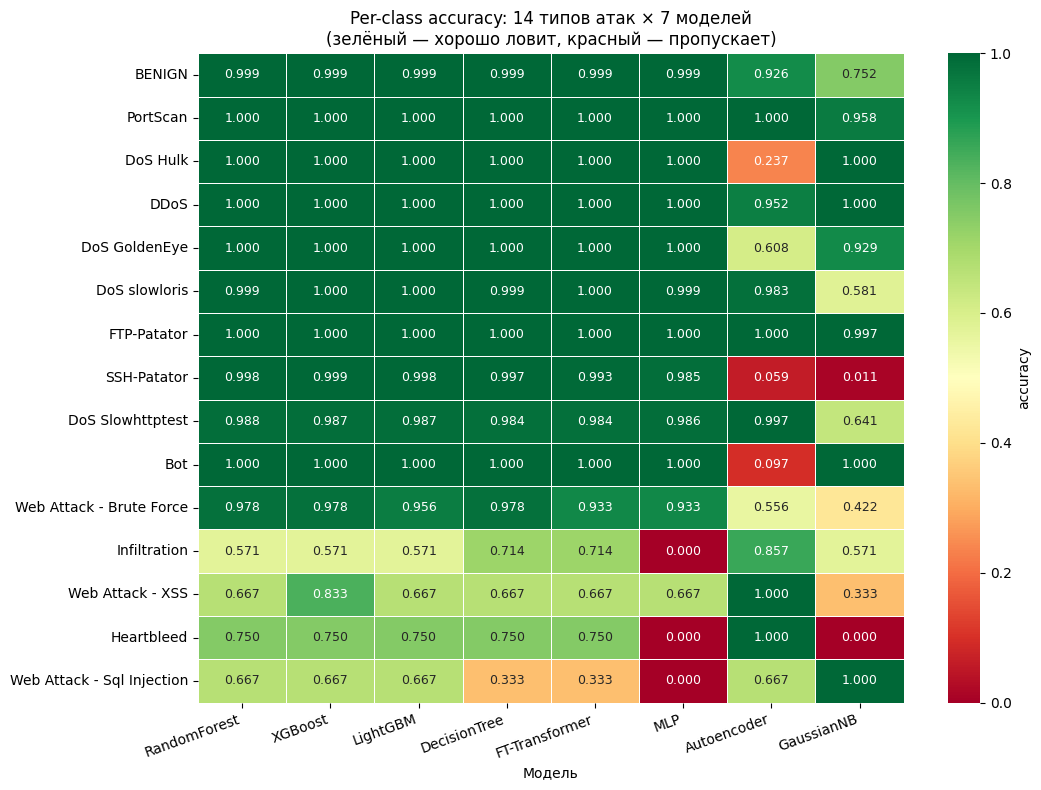

In [ ]:
pc_for_plot = pc_wide.drop(columns="n_total")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    pc_for_plot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.0, vmax=1.0,
    cbar_kws={"label": "accuracy"}, linewidths=0.5, linecolor="white",
    annot_kws={"size": 9}, ax=ax,
)
ax.set_title("Per-class accuracy: 14 типов атак × 7 моделей\n"
             "(зелёный — хорошо ловит, красный — пропускает)",
             fontsize=12)
ax.set_xlabel("Модель")
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_per_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Сводные ROC и PR-curves всех 7 моделей

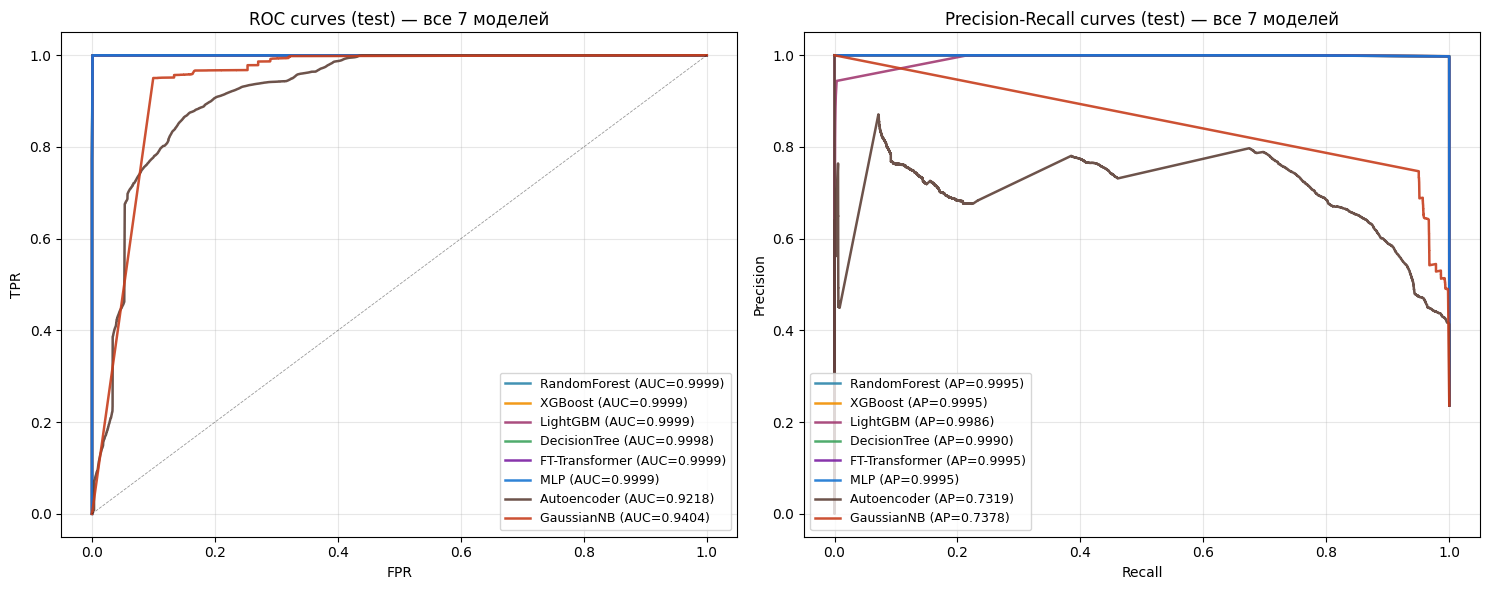

In [9]:
colors = {
    "RandomForest":   "#2E86AB",
    "XGBoost":        "#F18F01",
    "LightGBM":       "#A23B72",
    "DecisionTree":   "#3DA35D",
    "GaussianNB":     "#C73E1D",
    "MLP":            "#1976D2",
    "FT-Transformer": "#7B1FA2",
    "Autoencoder":    "#5D4037",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Порядок легенды — по F1
ordered_names = final["model"].tolist()

for name in ordered_names:
    res = scoring_results[name]
    fpr, tpr, _ = roc_curve(y_test, res["y_score"])
    auc = res["metrics"]["roc_auc"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})",
                 color=colors[name], lw=1.8, alpha=0.9)
axes[0].plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curves (test) — все 7 моделей")
axes[0].legend(loc="lower right", fontsize=9); axes[0].grid(alpha=0.3)

for name in ordered_names:
    res = scoring_results[name]
    prec, rec, _ = precision_recall_curve(y_test, res["y_score"])
    ap = res["metrics"]["pr_auc"]
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.4f})",
                 color=colors[name], lw=1.8, alpha=0.9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test) — все 7 моделей")
axes[1].legend(loc="lower left", fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_roc_pr_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

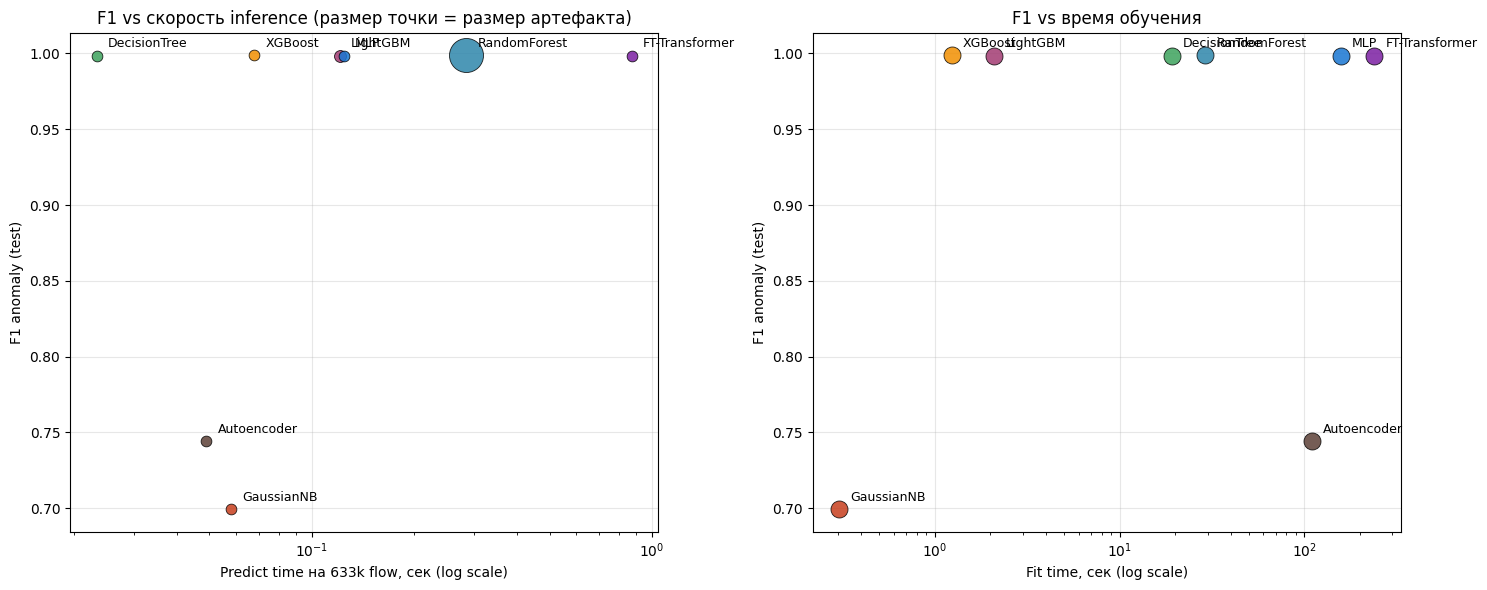

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) F1 vs predict_time, размер точки = size_kb
for name in ordered_names:
    res = scoring_results[name]
    x = res["predict_time"]
    y = res["metrics"]["f1_anomaly"]
    s = max(60, min(600, res["size_kb"] * 0.5))
    axes[0].scatter(x, y, s=s, color=colors[name], label=name,
                    edgecolor="black", linewidth=0.6, zorder=3, alpha=0.85)
    axes[0].annotate(name, (x, y), textcoords="offset points",
                     xytext=(8, 6), fontsize=9)
axes[0].set_xscale("log")
axes[0].set_xlabel("Predict time на 633k flow, сек (log scale)")
axes[0].set_ylabel("F1 anomaly (test)")
axes[0].set_title("F1 vs скорость inference (размер точки = размер артефакта)")
axes[0].grid(alpha=0.3)

# (b) F1 vs fit_time
for name in ordered_names:
    res = scoring_results[name]
    if res["fit_time"] is None:
        continue
    x = res["fit_time"]
    y = res["metrics"]["f1_anomaly"]
    axes[1].scatter(x, y, s=150, color=colors[name], label=name,
                    edgecolor="black", linewidth=0.6, zorder=3, alpha=0.85)
    axes[1].annotate(name, (x, y), textcoords="offset points",
                     xytext=(8, 6), fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlabel("Fit time, сек (log scale)")
axes[1].set_ylabel("F1 anomaly (test)")
axes[1].set_title("F1 vs время обучения")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_f1_vs_time_size.png", dpi=150, bbox_inches="tight")
plt.show()

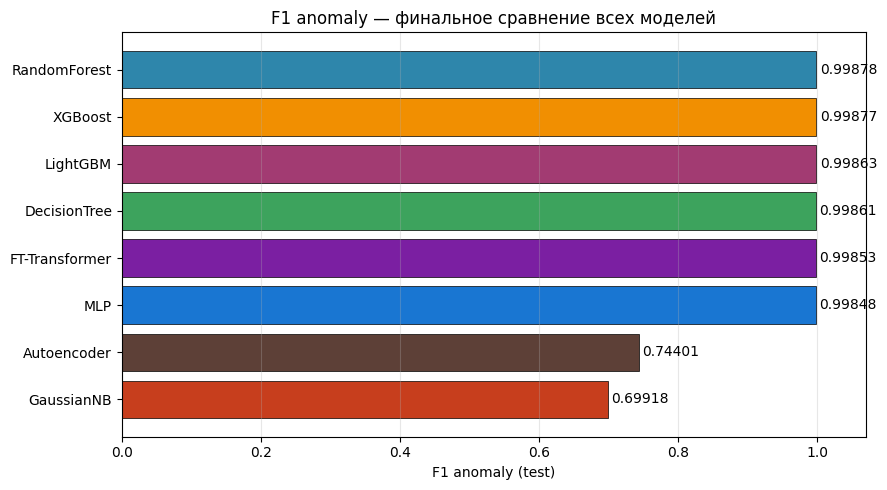

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
order = final.sort_values("f1_anomaly", ascending=True)
ax.barh(order["model"], order["f1_anomaly"],
        color=[colors[m] for m in order["model"]],
        edgecolor="black", lw=0.5)
for i, (_, row) in enumerate(order.iterrows()):
    ax.text(row["f1_anomaly"] + 0.005, i,
            f"{row['f1_anomaly']:.5f}", va="center", fontsize=10)
ax.set_xlabel("F1 anomaly (test)")
ax.set_title("F1 anomaly — финальное сравнение всех моделей")
ax.set_xlim(0, 1.07)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_f1_bar_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Генерация model_registry_manifest.json

Единый JSON-реестр всех артефактов с полной информацией для воспроизведения

In [12]:
manifest = {
    "project":      "NFS-2023-nTE binary anomaly detection",
    "manifest_version": "1.0",
    "generated_at":  datetime.now().isoformat(timespec="seconds"),
    "random_state":  RANDOM_STATE,
    "preprocessor": {
        "file":     "preprocessor.joblib",
        "config":   "preprocessing_config.json",
        "n_features_in":  42,
        "n_features_out": 42,
        "split": {
            "method":       "stratified_random",
            "test_size":    0.30,
            "random_state": RANDOM_STATE,
        },
    },
    "model_features": MODEL_FEATURES,
    "n_features":     42,
    "feature_names_file": "feature_names.json",
    "models": [],
    "src_files_required": [
        "src/metrics.py",
        "models/architectures.py",
    ],
}

for name, res in scoring_results.items():
    art_path = ARTIFACTS / res["file"]
    art = joblib.load(art_path)
    entry = {
        "name":              name,
        "file":              res["file"],
        "category":          res["category"],
        "type":              res["kind"],
        "model_class_name":  art["model_class_name"],
        "score_type":        art.get("score_type", "predict_proba"),
        "decision_threshold": art.get("decision_threshold"),
        "metrics_test": {
            k: round(v, 6) if isinstance(v, float) else v
            for k, v in res["metrics"].items()
        },
        "fit_time_sec":          res["fit_time"],
        "predict_time_test_sec": res["predict_time"],
        "size_kb":               res["size_kb"],
    }
    # Дополнительная информация для нейросетей
    if res["kind"] == "pytorch":
        entry["model_config"]    = art["model_config"]
        entry["n_params"]        = art.get("n_params")
        entry["architecture_module"] = art.get("architecture_module")
    manifest["models"].append(entry)

# Сохраняем
manifest_path = ARTIFACTS / "model_registry_manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)
print(f"Сохранено: {manifest_path}")
print(f"Размер: {manifest_path.stat().st_size / 1024:.1f} KB")
print(f"\nКлючи верхнего уровня: {list(manifest.keys())}")
print(f"Моделей в реестре: {len(manifest['models'])}")

Сохранено: /workspace/diplom_finals/research/artifacts/model_registry_manifest.json
Размер: 8.8 KB

Ключи верхнего уровня: ['project', 'manifest_version', 'generated_at', 'random_state', 'preprocessor', 'model_features', 'n_features', 'feature_names_file', 'models', 'src_files_required']
Моделей в реестре: 8


## Шаг 7. Финальный список всех артефактов

In [15]:
print(f"=== Содержимое {ARTIFACTS} ===\n")
total_size = 0
for p in sorted(ARTIFACTS.iterdir()):
    size_kb = p.stat().st_size / 1024
    total_size += size_kb
    print(f"  {p.name:40s} {size_kb:>10,.1f} KB")
print(f"\n  {'Итого:':40s} {total_size:>10,.1f} KB "
      f"({total_size / 1024:.2f} MB)")

=== Содержимое /workspace/diplom_finals/research/artifacts ===

  README.md                                       5.0 KB
  architectures.py                               11.4 KB
  feature_names.json                              1.2 KB
  metrics.py                                      3.5 KB
  model_autoencoder.joblib                       22.5 KB
  model_decisiontree.joblib                      17.8 KB
  model_ft_transformer.joblib                   107.6 KB
  model_gaussiannb.joblib                         2.0 KB
  model_lightgbm.joblib                         147.7 KB
  model_mlp.joblib                               65.3 KB
  model_registry_manifest.json                    8.8 KB
  model_rf_baseline.joblib                    1,896.4 KB
  model_xgboost.joblib                           79.4 KB
  preprocessing_config.json                       2.9 KB
  preprocessor.joblib                             2.0 KB
  split_meta.json                                 0.2 KB

  Итого:               

# Итоги исследования

### 1) Что сделано

9 ноутбуков (01-09) + 7 моделей + полная инфраструктура препроцессинга.
Общий объём артефактов: 2.3 MB на 8 файлов joblib + manifest + вспомогательный код

### 2) Финальный рейтинг моделей (test, 633 340 flow)

| model           | category         | F1_anomaly | errors | fit, сек | throughput, flow/sec | size, KB |
|-----------------|------------------|-----------:|-------:|---------:|---------------------:|---------:|
| RandomForest    | tree_ensemble    | 0.99878    | 365    | 29.16    | 2 225 255            | 1896.4   |
| **XGBoost**     | tree_ensemble    | **0.99877** | **368** | **1.23** | **9 360 943**       | **79.4** |
| LightGBM        | tree_ensemble    | 0.99863    | 411    | 2.10     | 5 233 666            | 147.7    |
| **DecisionTree** | tree_single     | 0.99861    | 418    | 19.20    | **27 171 487**       | **17.8** |
| FT-Transformer  | nn_supervised    | 0.99853    | 441    | 238.92   | 726 186              | 107.6    |
| MLP             | nn_supervised    | 0.99848    | 456    | 158.02   | 5 097 120            | 65.3     |
| **Autoencoder** | nn_unsupervised  | 0.74401    | 75 683 | 109.61   | 12 933 039           | 22.5     |
| GaussianNB      | linear_baseline  | 0.69918    | 124 610 | 0.30    | 10 944 698           | 2.0      |

### 3. Главное наблюдение: задача решена до максимального порога

**Все 6 supervised-моделей лежат в диапазоне F1 = [0.99848, 0.99878]** —
разброс **0.0003 п.п.** Разница между лучшей (RF) и худшей supervised-NN
(MLP) — это **91 единичная ошибка из 633k**, что находится в зоне
статистического шума при бинарной классификации на этом датасете.

Дальнейшее улучшение F1 невозможно без смены постановки задачи:
переход к multi-class, например.

### 4. Выбор production-модели — XGBoost

XGBoost оказался оптимальным выбором по совокупности 4 метрик:

| метрика                | XGBoost  | ближайший конкурент          | разрыв |
|------------------------|---------:|------------------------------|-------:|
| F1_anomaly             | 0.99877  | RF 0.99878                   | 0.001 п.п. |
| Fit time               | 1.23 сек | LightGBM 2.10 сек            | x1.7   |
| Inference throughput   | 9.4M f/s | LightGBM 5.2M f/s            | x1.8   |
| Artifact size          | 79 KB    | DecisionTree 18 KB           | n/a    |

DecisionTree быстрее на inference (27M f/s vs 9.4M) и меньше по размеру
(18 KB vs 79 KB), но проигрывает по F1 на 0.0002 п.п. — в production
эта разница в 53 ошибочно-классифицированных flow несущественна, поэтому
DT — резервный вариант для ультра-быстрого inference.

### 5. Per-class accuracy — главная содержательная картина

Heatmap показывает 14 типов атак и 8 моделей.
Из него видны три качественно различных режима поведения моделей:

**Зона полной согласованности (массовые классы):** PortScan, DoS Hulk,
DDoS, DoS GoldenEye, DoS slowloris, FTP-Patator, SSH-Patator, Bot,
Web Attack BF, DoS Slowhttptest — все 6 supervised-моделей дают
accuracy 0.98–1.00. Это и есть та доля атак, на которой задача
тривиально решается tree-based методами.

**Зона расхождения подходов (редкие классы, <10 примеров):**

| класс             | n_total | tree-based | MLP | FT-Trans | AE |
|-------------------|--------:|-----------:|----:|---------:|---:|
| Infiltration      | 7       | 0.57       | **0.00** | 0.71 | **0.86** |
| Heartbleed        | 4       | 0.75       | **0.00** | 0.75 | **1.00** |
| Web Attack - XSS  | 6       | 0.67-0.83  | 0.67 | 0.67    | **1.00** |
| SQL Injection     | 3       | 0.67       | **0.00** | 0.33 | 0.67 |

**Ключевая находка исследования:**
- **MLP полностью заваливает Heartbleed, Infiltration и SQL Injection** —
  модель не выучивает сигнатуры классов с <10 train-примерами.
- **FT-Transformer восстанавливает Heartbleed и Infiltration** благодаря
  attention-механизму, который строит контекстные представления вместо
  запоминания массовых паттернов.
- **Autoencoder доминирует на 4 редких классах**, потому что они
  структурно отличны от обычного трафика и дают высокую reconstruction
  error.

**Зона провала AE (массовые HTTP/SSH атаки):** DoS Hulk 24%, SSH-Patator 6%, Bot 10%. Эти атаки flow-структурно неотличимы от легитимного трафика — AE их успешно восстанавливает как BENIGN
и не детектирует. Это **структурное ограничение one-class подхода**, не результат недообучения (на 50 эпохах модель полностью сошлась без переобучения).

### 6. Сравнение подходов

Модели в проекте не **закрывают разные спекты задачи IDS**:

| подход             | сильные стороны                    | ограничения                       |
|--------------------|-----------------------------------|-----------------------------------|
| Tree-based (XGB)   | Лучший F1, скорость, малый размер | Зависит от меток                  |
| NN supervised (MLP)| Конкурентен tree-based            | Провал на редких классах          |
| NN с attention (FT)| Интерпретация через attention карты + восстановление редких классов | Дороже на train в x190 vs XGBoost |
| Unsupervised (AE)  | Не требует меток + ловит редкие/новые атаки лучше всех | F1 на 25 п.п. ниже supervised   |

### 7. Итоговый выбор для production

На основе результатов проекта обоснованная гибридная схема для реальной
IDS-системы:

1. **Primary detector — XGBoost.** F1=0.998 на массовых атаках,
   9.4M flow/sec throughput, 79 KB модель. Решает 99.9% случаев.

2. **Secondary detector — Autoencoder (one-class).** Запускается
   параллельно на тех же flow. Высокий reconstruction error на flow,
   которые primary счёл BENIGN, — сигнал для эскалации к аналитику.
   Особенно эффективен на редких/новых атаках (Heartbleed 100%,
   Infiltration 86%, XSS 100%).

3. **Explainer — FT-Transformer.** Не для production decision-making,
   а как инструмент анализа: при поступлении alert от primary можно
   показать attention map — какие признаки и их взаимодействия
   привели к решению. Это интерпретируемость, недоступная для
   tree-based моделей.
